## Resume Dataset Analysis Notebook

### 1. Setup & Imports

In [2]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text processing
import re
from collections import Counter

# NLP (optional advanced)
from sklearn.feature_extraction.text import CountVectorizer

# Settings
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

### 2. Load Dataset

In [5]:
# Load data
df = pd.read_csv("../data/resume.csv")

# Preview
df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [6]:
# Basic info
df.info()

# Check missing values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           2484 non-null   int64 
 1   Resume_str   2484 non-null   object
 2   Resume_html  2484 non-null   object
 3   Category     2484 non-null   object
dtypes: int64(1), object(3)
memory usage: 77.8+ KB


ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64

### 3. Data Cleaning

In [7]:
# Drop duplicates
df = df.drop_duplicates()

# Handle missing values
df['Resume_str'] = df['Resume_str'].fillna('')
df['Resume_html'] = df['Resume_html'].fillna('')
df['Category'] = df['Category'].fillna('Unknown')

### 4. Basic Dataset Overview

##### Category Distribution

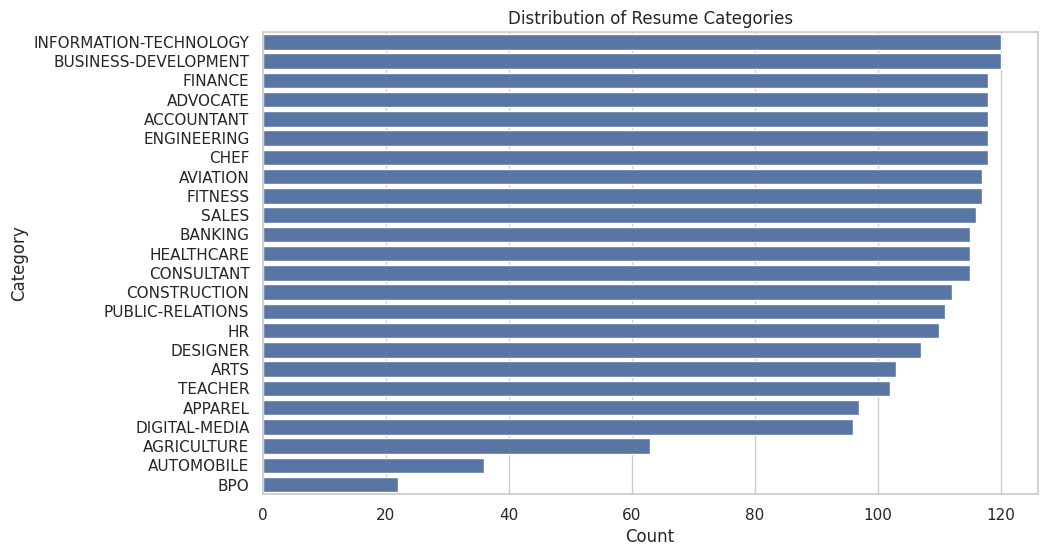

In [8]:
category_counts = df['Category'].value_counts()

plt.figure()
sns.barplot(x=category_counts.values, y=category_counts.index)
plt.title("Distribution of Resume Categories")
plt.xlabel("Count")
plt.ylabel("Category")
plt.show()

##### Pie Chart

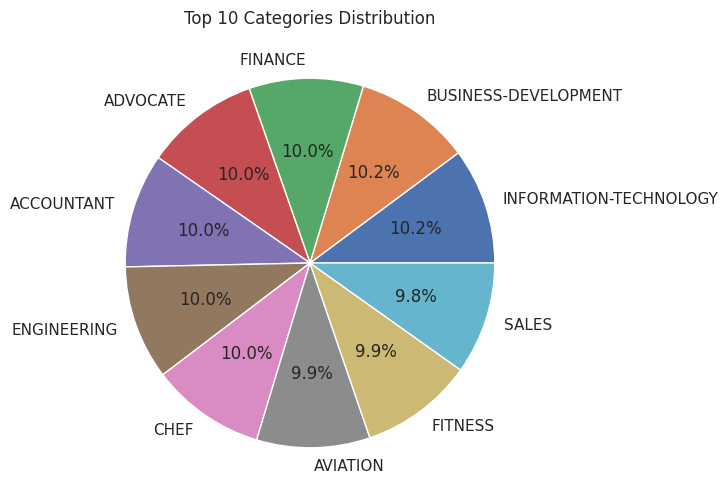

In [9]:
category_counts.head(10).plot.pie(autopct='%1.1f%%')
plt.title("Top 10 Categories Distribution")
plt.ylabel('')
plt.show()

### 5. Resume Length Analysis

In [10]:
# Add length features
df['char_length'] = df['Resume_str'].apply(len)
df['word_count'] = df['Resume_str'].apply(lambda x: len(x.split()))

##### Distribution Plots

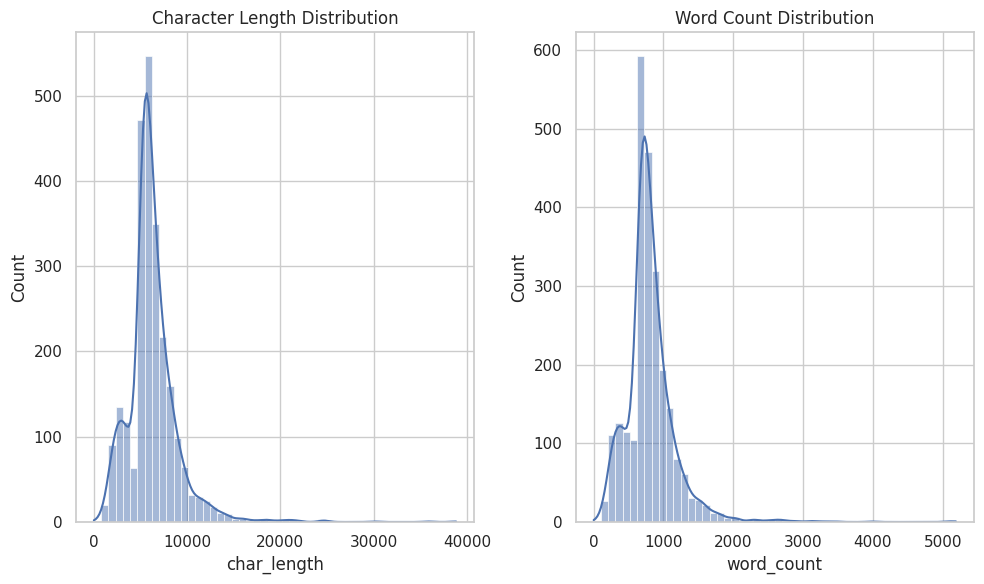

In [12]:
fig, axes = plt.subplots(1, 2)

sns.histplot(df['char_length'], bins=50, ax=axes[0], kde=True)
axes[0].set_title("Character Length Distribution")

sns.histplot(df['word_count'], bins=50, ax=axes[1], kde=True)
axes[1].set_title("Word Count Distribution")

plt.tight_layout()
plt.show()

### 6. Category vs Resume Length

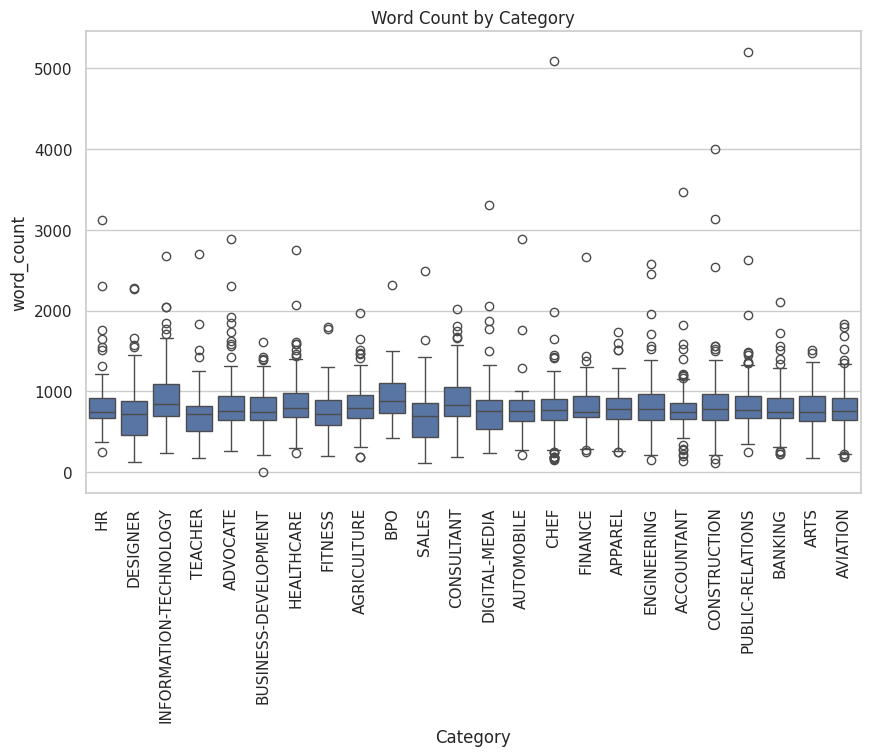

In [13]:
plt.figure()
sns.boxplot(data=df, x='Category', y='word_count')
plt.xticks(rotation=90)
plt.title("Word Count by Category")
plt.show()

##### 7. Text Cleaning Function

In [14]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\W+', ' ', text)
    text = re.sub(r'\d+', '', text)
    return text

df['cleaned_resume'] = df['Resume_str'].apply(clean_text)

##### 8. Most Common Words

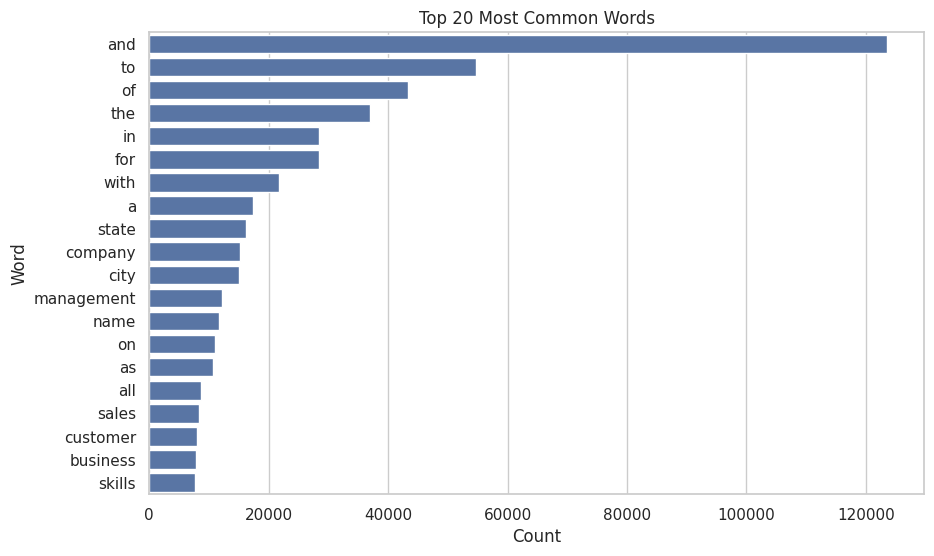

In [15]:
all_words = ' '.join(df['cleaned_resume']).split()
word_freq = Counter(all_words)

common_words = pd.DataFrame(word_freq.most_common(20), columns=['Word', 'Count'])

sns.barplot(data=common_words, x='Count', y='Word')
plt.title("Top 20 Most Common Words")
plt.show()

##### 9. Category-Specific Keywords

In [16]:
def get_top_words(text_series, n=10):
    words = ' '.join(text_series).split()
    return Counter(words).most_common(n)

categories = df['Category'].unique()

for cat in categories[:5]:  # limit for display
    print(f"\nTop words in {cat}:")
    print(get_top_words(df[df['Category'] == cat]['cleaned_resume']))


Top words in HR:
[('and', 6011), ('to', 2408), ('of', 1860), ('the', 1777), ('for', 1489), ('in', 1234), ('hr', 1057), ('with', 968), ('management', 949), ('employee', 828)]

Top words in DESIGNER:
[('and', 4539), ('to', 2243), ('of', 1524), ('the', 1458), ('for', 1181), ('in', 1093), ('design', 938), ('with', 878), ('city', 728), ('state', 722)]

Top words in INFORMATION-TECHNOLOGY:
[('and', 6856), ('to', 2803), ('of', 2339), ('the', 2322), ('for', 1520), ('in', 1250), ('with', 977), ('a', 909), ('management', 898), ('information', 860)]

Top words in TEACHER:
[('and', 4595), ('to', 2268), ('of', 1503), ('the', 1262), ('in', 1215), ('with', 1020), ('for', 1001), ('a', 731), ('state', 728), ('students', 699)]

Top words in ADVOCATE:
[('and', 6203), ('to', 2983), ('of', 2017), ('the', 1679), ('in', 1526), ('for', 1324), ('with', 1188), ('state', 922), ('city', 832), ('a', 820)]


##### 10. N-Gram Analysis (Advanced)

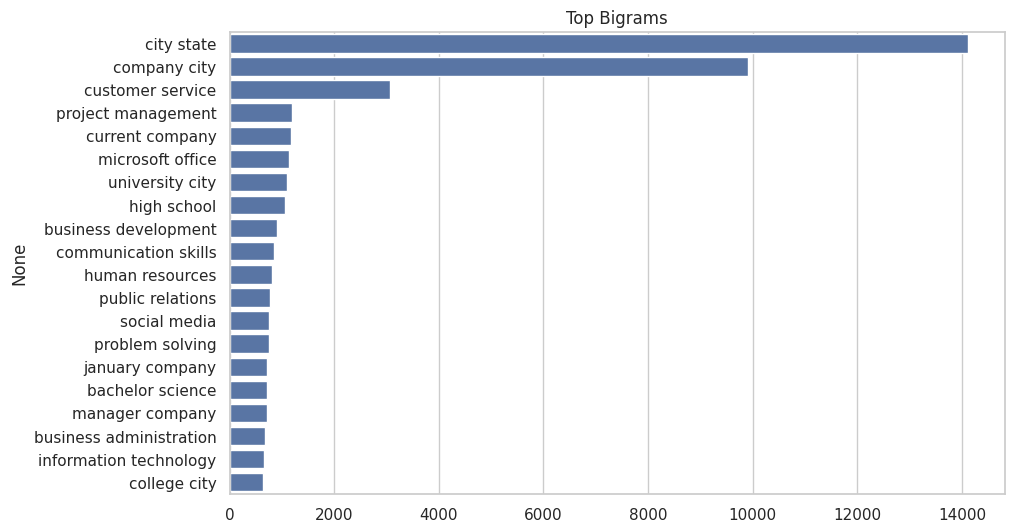

In [18]:
vectorizer = CountVectorizer(ngram_range=(2,2), stop_words='english', max_features=20)
X = vectorizer.fit_transform(df['cleaned_resume'])

bigram_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())

bigram_counts = bigram_df.sum().sort_values(ascending=False)

sns.barplot(x=bigram_counts.values, y=bigram_counts.index)
plt.title("Top Bigrams")
plt.show()

##### 11. Correlation Analysis

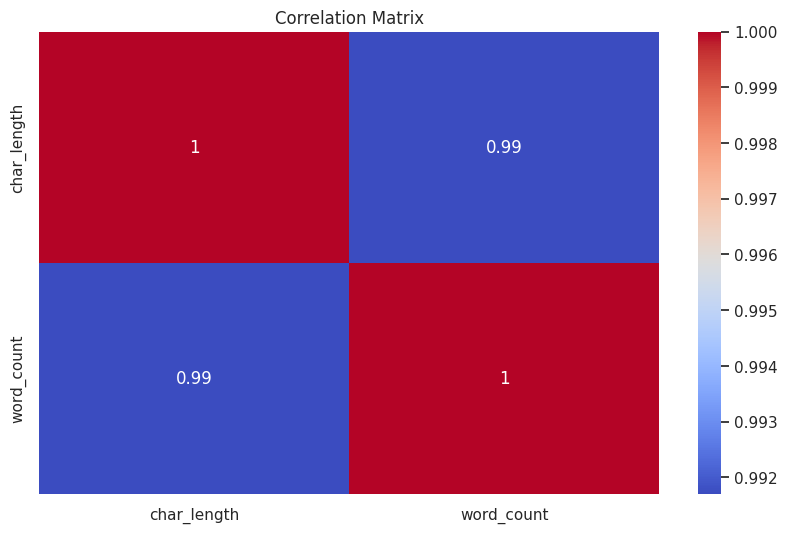

In [19]:
corr = df[['char_length', 'word_count']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [21]:
df.to_csv("../data/cleaned_resume.csv", index=False)